# 🔬 Understanding CellProfiler Features with Synthetic Cells

## Why does this matter?

When biologists image cells under a microscope, the cells land in the dish at **random orientations**. A cell pointing "up" and the same cell pointing "sideways" are biologically identical — they are the same cell, just rotated.

**CellProfiler** is the most widely-used software in the world for automatically measuring properties of cells from microscopy images. It extracts hundreds of numerical *features* from each cell image: its area, its shape, how brightly it stains, how the staining varies across the cell, and much more.

Ideally, **every CellProfiler feature should be rotation-invariant** — it should give the same number regardless of how the cell happens to be oriented. If a feature changes just because the cell is rotated, that change is a *measurement artifact*, not biology. Using such features in downstream analysis (comparing drug treatments, patient samples, etc.) would introduce false differences that have nothing to do with the biology you care about.

In practice, **some CellProfiler features are not rotation-invariant**. This is the problem we are trying to characterize.

## Our approach: synthetic cells

To test rotation sensitivity systematically, we use **synthetic cells** generated by the `cellgenerator` package:

- We construct a cell with a perfectly known shape and staining pattern.
- We rotate it by a precise angle.
- We pass both the original and the rotated images through CellProfiler.
- Any feature that changes is, by definition, rotation-sensitive.

This approach is powerful because there is no ambiguity: the cell has not changed biologically — **only its orientation has changed**. Any measured difference is pure artifact.

## What this notebook demonstrates

1. How to generate synthetic cells with controlled properties
2. How to extract all CellProfiler features using `cellgenerator`'s built-in pipeline
3. What the ~200 CellProfiler features actually measure (in plain language)
4. Which features are stable under rotation and which are sensitive
5. How to quantify and visualize rotation sensitivity

---
> **Note on CellProfiler setup:** Feature extraction requires the `cg-cellprofiler` conda environment.
> Sections 1–3 (image generation and visualization) run without it.
> See `docs/setup/cellprofiler.md` or run `conda env create -f environment.yml` to set it up.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from cellgenerator import Image
from cellgenerator.mask import CircleMask, EllipseMask
from cellgenerator.stain import ConstantStain, SpatialStain
from cellgenerator.measure import CellProfilerMeasurer, CellProfilerNotFoundError

# ── Reproducibility ───────────────────────────────────────────────────────────
# SpatialStain uses random numbers; fixing the seed ensures the notebook
# produces the same images every time it is run.
np.random.seed(42)

# ── Display settings ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Imports successful')

✓ Imports successful


---
## Section 1 — What is a Synthetic Cell?

A synthetic cell in `cellgenerator` is built from three independent components:

| Component | What it defines | Examples |
|-----------|----------------|----------|
| **Mask** | The *shape* of the cell — which pixels are "inside" | Circle, ellipse |
| **Stain** | The *intensity pattern* across the cell — how bright each region is | Uniform (flat), spatially-correlated (realistic) |
| **Noise** | Random pixel-level variation on top of the stain | None (default), Gaussian, Poisson |

The components are combined like this:

```
final pixel value  =  mask  ×  stain  +  noise
                     (0 or 1)   (brightness)
```

The image is first generated at a **high internal resolution** (e.g. 1000×1000 pixels) and then rotated and rescaled to whatever output size you need. This two-step approach means the cell retains fine detail even after downsampling.

In this notebook we will create **three example cells** of increasing complexity:

1. **Circle, constant stain** — the simplest possible cell. Perfectly symmetric. A reference for what "rotation-invariant" looks like.
2. **Ellipse, constant stain** — elongated cell with uniform brightness. Orientation matters for shape features, but intensity is trivially constant.
3. **Ellipse, spatially-correlated stain** — the most realistic. The staining pattern is not uniform, so rotating the cell also rotates the staining gradient, which is what happens in real microscopy images.

In [2]:
# ── Resolution settings ───────────────────────────────────────────────────────
# INTERNAL_DIM: the resolution at which the cell is generated internally.
#   Higher = more detail, slower.  1000×1000 is a good default.
# OUTPUT_DIM:   the resolution at which images are saved / passed to CellProfiler.
#   Larger = more features captured, slower CellProfiler run.
INTERNAL_DIM = (1000, 1000)
OUTPUT_DIM   = (200, 200)

# ── Cell 1: Circle with constant (uniform) staining ───────────────────────────
# CircleMask(radius=300) places a circle of radius 300 px at the centre of
# the 1000×1000 canvas.  ConstantStain() fills the interior with a uniform
# brightness of 1.0 (maximum).
cell_circle = Image(
    dim=INTERNAL_DIM,
    mask=CircleMask(radius=300),
    stain=ConstantStain(),
)

# ── Cell 2: Elongated ellipse with constant staining ─────────────────────────
# EllipseMask(y_radius=150, x_radius=400) creates a wide, flat ellipse —
# like a cell that has spread out horizontally.  y_radius < x_radius makes
# it wider than it is tall.  The eccentricity (how "stretched" it is) is
# a biologically meaningful quantity CellProfiler measures.
cell_ellipse_flat = Image(
    dim=INTERNAL_DIM,
    mask=EllipseMask(y_radius=150, x_radius=400),
    stain=ConstantStain(),
)

# ── Cell 3: Elongated ellipse with spatially-correlated staining ─────────────
# SpatialStain(y_corr=40, x_corr=40) generates a staining pattern that
# varies smoothly across the cell — brighter in some regions, dimmer in others.
# This mimics the way real fluorescence stains are never perfectly uniform.
# The numbers (y_corr, x_corr) control the spatial scale of the variation:
#   larger → broader, more gradual gradients
#   smaller → fine-grained, speckled variation
np.random.seed(42)   # reset so the stain pattern is reproducible
cell_ellipse_spatial = Image(
    dim=INTERNAL_DIM,
    mask=EllipseMask(y_radius=150, x_radius=400),
    stain=SpatialStain(y_corr=40, x_corr=40),
)

CELLS = {
    'Circle\n(constant stain)':          cell_circle,
    'Ellipse\n(constant stain)':         cell_ellipse_flat,
    'Ellipse\n(spatially-correlated stain)': cell_ellipse_spatial,
}

print(f'Created {len(CELLS)} synthetic cells at {INTERNAL_DIM} internal resolution.')
print(f'Output (display + CellProfiler) resolution: {OUTPUT_DIM}')

Created 3 synthetic cells at (1000, 1000) internal resolution.
Output (display + CellProfiler) resolution: (200, 200)


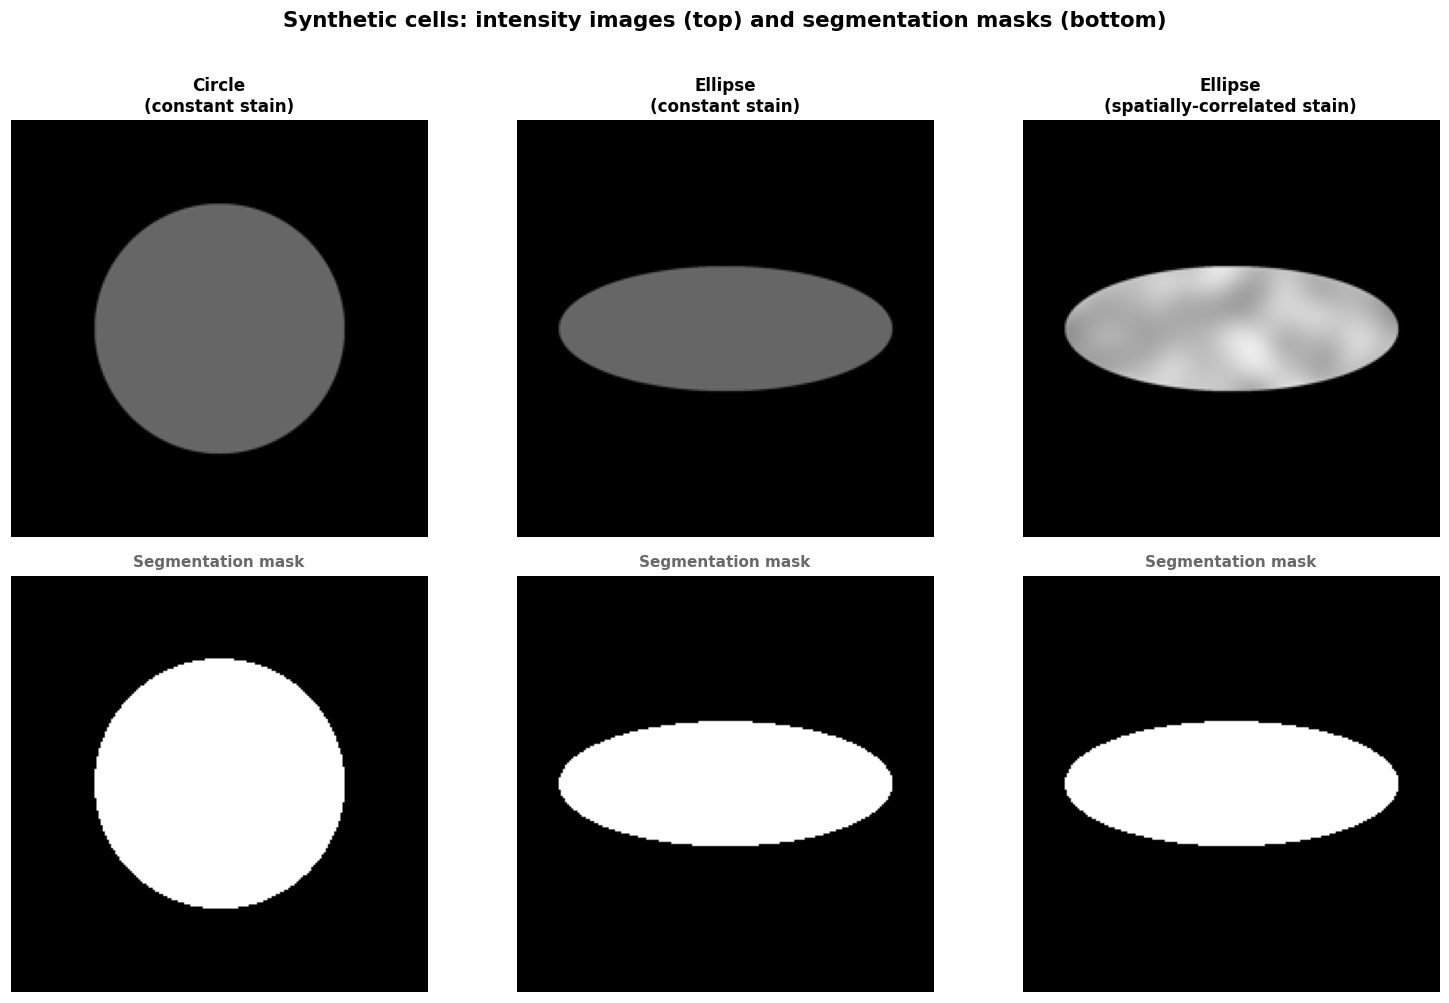


Key observations:
  • The mask is binary (0 or 1) — it is the PERFECT segmentation,
    because we built the cell from it.
  • The ellipse with spatial stain has a non-uniform intensity pattern.
    This is what makes texture features challenging for rotation.


In [3]:
# ── Visualise: intensity images (top row) and masks (bottom row) ──────────────
#
# The TOP row shows what CellProfiler "sees" as the fluorescence channel —
# the greyscale image of the cell.
#
# The BOTTOM row shows the segmentation mask — which pixels belong to the cell
# (white = cell, black = background).  Because these are synthetic cells, we
# already know the mask perfectly: it is the same boolean array we used to
# build the cell.  No thresholding or machine-learning segmentation is needed.
# This is the key advantage of the synthetic approach.

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Synthetic cells: intensity images (top) and segmentation masks (bottom)',
             fontsize=14, fontweight='bold', y=1.01)

for col, (name, cell) in enumerate(CELLS.items()):
    # Render intensity image at output resolution, 0° rotation
    intensity = np.array(cell.get_img(OUTPUT_DIM, rotate=0))
    # Render mask — the ground-truth segmentation
    mask      = np.array(cell.get_mask_img(OUTPUT_DIM, rotate=0))

    # Top row: fluorescence channel
    ax_top = axes[0, col]
    ax_top.imshow(intensity, cmap='gray', vmin=0, vmax=255)
    ax_top.set_title(name, fontsize=11)
    ax_top.axis('off')

    # Bottom row: segmentation mask
    ax_bot = axes[1, col]
    ax_bot.imshow(mask, cmap='gray', vmin=0, vmax=1)
    ax_bot.set_title('Segmentation mask', fontsize=10, color='dimgray')
    ax_bot.axis('off')

    # Draw a coloured border to visually link the two rows
    for ax in [ax_top, ax_bot]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(['steelblue', 'darkorange', 'seagreen'][col])
            spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()

print('\nKey observations:')
print('  • The mask is binary (0 or 1) — it is the PERFECT segmentation,')
print('    because we built the cell from it.')
print('  • The ellipse with spatial stain has a non-uniform intensity pattern.')
print('    This is what makes texture features challenging for rotation.')

---
## Section 2 — The Rotation Problem

In a real experiment, cells land on a microscope slide at random orientations. The cell shown below is the **same cell** at six different rotation angles — nothing has changed biologically, but the image looks different.

This raises the critical question: **do CellProfiler features change when we rotate the cell?**

Some features *should* change — for example, `AreaShape_Orientation` literally measures "which direction is the long axis pointing", so it is *supposed* to reflect rotation. But most features — area, mean brightness, texture — should ideally stay the same, because they describe intrinsic properties of the cell, not its orientation.

When a feature changes with rotation, it means:
- If you compare a group of cells from one dish to another, some cells may be oriented differently.
- That orientation difference will look like a biological difference in your data.
- That is a false positive — an artefact, not biology.

Below, we show the elongated ellipse (with spatially-correlated stain) at 0°, 60°, 120°, 180°, 240°, and 300°.

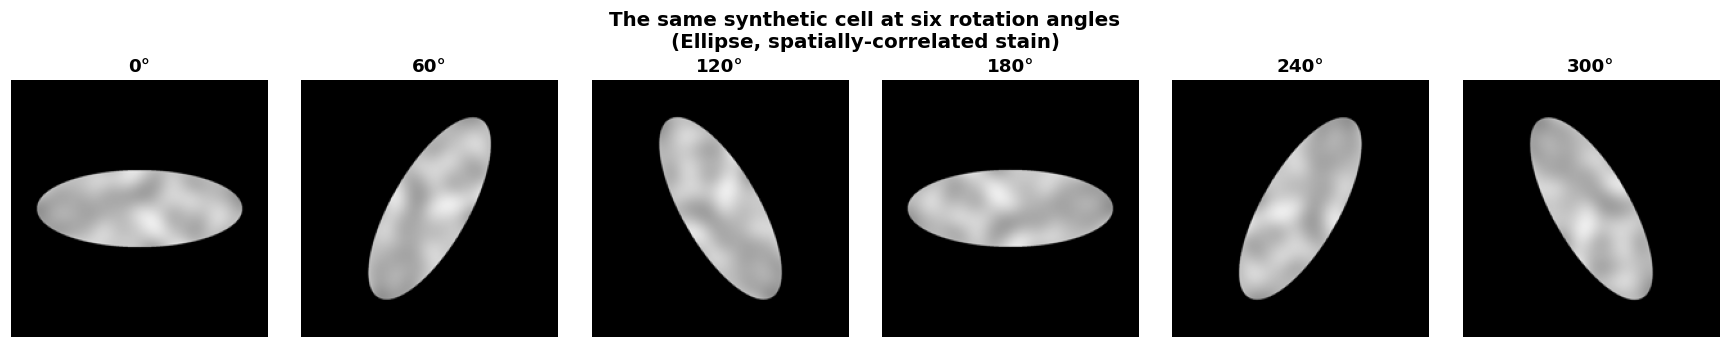

The cell content is identical at every angle — only the orientation differs.
Any CellProfiler feature that gives a different value across these images
is rotation-sensitive and may introduce artefacts in downstream analysis.


In [4]:
# ── Show the spatially-stained ellipse at 6 rotation angles ──────────────────
demo_angles = [0, 60, 120, 180, 240, 300]

fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
fig.suptitle(
    'The same synthetic cell at six rotation angles\n'
    '(Ellipse, spatially-correlated stain)',
    fontsize=13, fontweight='bold'
)

for ax, angle in zip(axes, demo_angles):
    img_arr = np.array(cell_ellipse_spatial.get_img(OUTPUT_DIM, rotate=float(angle)))
    ax.imshow(img_arr, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{angle}°', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('The cell content is identical at every angle — only the orientation differs.')
print('Any CellProfiler feature that gives a different value across these images')
print('is rotation-sensitive and may introduce artefacts in downstream analysis.')

---
## Section 3 — Connecting to CellProfiler

### Why a separate environment?

CellProfiler is a large and mature piece of software with its own specific dependency requirements. It pins certain library versions that would conflict with the rest of `cellgenerator`'s tools. To avoid this, we run CellProfiler **inside a dedicated, isolated conda environment** called `cg-cellprofiler`.

`cellgenerator` communicates with it like this:

```
This notebook                         cg-cellprofiler conda env
─────────────────────                 ─────────────────────────────
CellProfilerMeasurer
  │  writes temp PNGs
  │  (intensity + mask)
  │
  └──────── subprocess ─────────────▶  _runner.py
                                         • loads images
                                         • builds CellProfiler workspace
                                         • runs measurement modules
                                         • prints JSON to stdout
                                              │
  pd.DataFrame ◀──── JSON parse ────────────┘
```

The `_runner.py` script (which ships with `cellgenerator`) runs **five CellProfiler measurement modules** inside that environment:

| Module | What it measures |
|--------|----------------|
| `MeasureObjectSizeShape` | Size, shape, and geometric properties (including Zernike moments) |
| `MeasureObjectIntensity` | Brightness statistics across the cell |
| `MeasureTexture` | Local texture patterns (Haralick features at multiple scales) |
| `MeasureGranularity` | The granularity spectrum — how "grainy" the staining is at different scales |
| `MeasureObjectRadialDistribution` | How intensity is distributed from the cell centre outward |

### Setup (run once)

```bash
conda env create -f environment.yml   # creates cg-cellprofiler
export CELLPROFILER_PYTHON="$(conda run -n cg-cellprofiler which python)"
```

See `docs/setup/cellprofiler.md` for full instructions.

In [5]:
# ── Connect to CellProfiler ───────────────────────────────────────────────────
# CellProfilerMeasurer() searches for the cg-cellprofiler conda environment
# automatically.  If it cannot find one, it raises CellProfilerNotFoundError
# and prints instructions.
#
# We catch the error gracefully here so the rest of the notebook can still
# run (the image generation sections do not require CellProfiler).

try:
    measurer = CellProfilerMeasurer()
    CELLPROFILER_AVAILABLE = True
    print(f'✓ CellProfiler found at: {measurer.python}')
    print('  Feature extraction is enabled.')
except CellProfilerNotFoundError as err:
    measurer = None
    CELLPROFILER_AVAILABLE = False
    print('⚠  CellProfiler environment not found.')
    print('   Sections 4–6 below will be skipped.')
    print('   To enable them, run:')
    print('     conda env create -f environment.yml')
    print('     export CELLPROFILER_PYTHON="$(conda run -n cg-cellprofiler which python)"')

⚠  CellProfiler environment not found.
   Sections 4–6 below will be skipped.
   To enable them, run:
     conda env create -f environment.yml
     export CELLPROFILER_PYTHON="$(conda run -n cg-cellprofiler which python)"


---
## Section 4 — Extracting All CellProfiler Features

The `measure()` method does three things:

1. Renders the synthetic cell as a greyscale PNG at the requested output size (`dim`) and rotation angle.
2. Renders the ground-truth mask as a label PNG (pixel value 0 = background, 1 = cell).
3. Passes both to CellProfiler's measurement pipeline and returns all numeric features as a **pandas DataFrame** — one row, one column per feature.

The result looks something like this (abbreviated):

| AreaShape_Area | AreaShape_Eccentricity | Intensity_MeanIntensity | Texture_Entropy_... | ... |
|:-:|:-:|:-:|:-:|:-:|
| 12450.0 | 0.92 | 0.71 | 3.14 | ... |

Let's extract features for the circle at 0° rotation and see what we get.

In [6]:
# ── Extract features for a single cell at a single angle ─────────────────────
if CELLPROFILER_AVAILABLE:
    print('Extracting CellProfiler features for the circle (0° rotation)...')
    print('(This takes ~10–30 seconds the first time — CellProfiler initialises its workspace.)\n')

    df_circle_0 = measurer.measure(cell_circle, dim=OUTPUT_DIM, rotate=0.0)

    # Separate the rotation metadata column from actual feature columns
    feature_cols = [c for c in df_circle_0.columns if c != 'rotate_deg']

    print(f'✓ Extracted {len(feature_cols)} features.')
    print(f'  Output DataFrame shape: {df_circle_0.shape}  (rows × columns)')
    print()

    # Show the first 15 feature names with their values
    print('First 15 features (name → value):')
    print('-' * 55)
    for col in feature_cols[:15]:
        val = df_circle_0[col].iloc[0]
        print(f'  {col:<45}  {val:>10.4f}')

else:
    print('(Skipped — CellProfiler not available)')
    print('Set up the cg-cellprofiler conda environment to run this section.')

(Skipped — CellProfiler not available)
Set up the cg-cellprofiler conda environment to run this section.


In [7]:
# ── Group features by category and visualise the distribution ─────────────────
#
# CellProfiler feature names follow a naming convention:
#   Category_SpecificMeasurement_[Optional_SubMeasurement]
#
# For example:
#   AreaShape_Area              → category: AreaShape, measure: Area
#   Intensity_MeanIntensity_CellImage → category: Intensity, ...
#   Texture_Entropy_CellImage_3_00 → category: Texture, ...
#
# The first component (before the first underscore) tells us which measurement
# module produced that feature.

if CELLPROFILER_AVAILABLE:
    # Parse the category from each feature name
    categories = {}
    for col in feature_cols:
        cat = col.split('_')[0]
        categories.setdefault(cat, []).append(col)

    print('Feature categories found:')
    print('-' * 40)
    for cat in sorted(categories):
        print(f'  {cat:<30}  {len(categories[cat]):>4} features')
    print('-' * 40)
    print(f'  {"TOTAL":<30}  {len(feature_cols):>4} features')
    print()

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 4))
    cat_names  = sorted(categories.keys())
    cat_counts = [len(categories[c]) for c in cat_names]
    colours = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

    bars = ax.bar(cat_names, cat_counts,
                  color=colours[:len(cat_names)],
                  edgecolor='white', linewidth=1.5)

    # Label each bar with its count
    for bar, count in zip(bars, cat_counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5, str(count),
                ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax.set_ylabel('Number of features', fontsize=12)
    ax.set_xlabel('CellProfiler feature category', fontsize=12)
    ax.set_title('How many features does each CellProfiler module produce?', fontsize=13)
    ax.set_ylim(0, max(cat_counts) * 1.2)
    ax.tick_params(axis='x', labelsize=11)
    plt.tight_layout()
    plt.show()

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


---
## Section 5 — What Does Each Feature Category Actually Measure?

Here is a plain-language guide to the five CellProfiler measurement modules used in this pipeline.

---

### 🔵 AreaShape — Size and Shape Features

These features describe the **geometry** of the cell object, purely from the segmentation mask (no intensity information is used).

| Feature | Plain-language meaning | Rotation-invariant? |
|---------|----------------------|--------------------|
| `AreaShape_Area` | Total number of pixels inside the cell | ✅ Should be invariant |
| `AreaShape_Perimeter` | Length of the cell's outer boundary | ✅ Should be invariant |
| `AreaShape_Eccentricity` | How elongated the cell is (0 = circle, 1 = line) | ✅ Should be invariant |
| `AreaShape_Orientation` | Angle (in degrees) of the major axis | ❌ Changes by design — this IS the rotation |
| `AreaShape_MajorAxisLength` | Length of the long axis of the best-fit ellipse | ✅ Should be invariant |
| `AreaShape_MinorAxisLength` | Length of the short axis of the best-fit ellipse | ✅ Should be invariant |
| `AreaShape_FormFactor` | How circular the cell is (1 = perfect circle) | ✅ Should be invariant |
| `AreaShape_Solidity` | Fraction of the convex hull that is filled | ✅ Should be invariant |
| `AreaShape_Zernike_*` | Zernike polynomial moments of the shape | ⚠️ Some vary with rotation |

---

### 🟠 Intensity — Brightness Features

These features describe **how bright the cell is** inside the segmented region.

| Feature | Plain-language meaning | Rotation-invariant? |
|---------|----------------------|--------------------|
| `Intensity_MeanIntensity` | Average pixel brightness inside the cell | ✅ Should be invariant |
| `Intensity_MaxIntensity` | Brightest pixel in the cell | ✅ Should be invariant for uniform stain |
| `Intensity_MinIntensity` | Dimmest pixel in the cell | ✅ Should be invariant |
| `Intensity_StdIntensity` | How much brightness varies inside the cell | ✅ Should be invariant |
| `Intensity_IntegratedIntensity` | Sum of all pixel brightnesses (area × mean) | ✅ Should be invariant |
| `Intensity_MassDisplacement` | Distance between the brightest region and the geometric centre | ⚠️ May vary with rotation |

---

### 🟢 Texture — Local Pattern Features

Texture features describe **how the brightness varies locally** within the cell. They use a statistical framework called the Grey-Level Co-occurrence Matrix (GLCM), also known as Haralick features. Essentially, they ask: "If I move one pixel to the right (or diagonally), how similar is the brightness to where I started?"

These features are measured at **multiple spatial scales** (typically 3, 5, and 10 pixels) and in **four directions** (0°, 45°, 90°, 135°).

| Feature | Plain-language meaning |
|---------|----------------------|
| `Texture_AngularSecondMoment` | How uniform the texture is (high = very uniform) |
| `Texture_Contrast` | How much local contrast exists |
| `Texture_Correlation` | How predictable a pixel's brightness is from its neighbour's |
| `Texture_Entropy` | How random/complex the texture appears |
| `Texture_InfoMeasCorr1/2` | Information-theoretic texture complexity |

> ⚠️ **Texture features are often rotation-sensitive** because they measure patterns along *specific pixel directions* (right, diagonal, etc.). When the cell rotates, the staining gradient rotates too, so "moving right" samples a different part of the gradient than before.

---

### 🔴 Granularity — Scale of Structural Patterns

Granularity features describe **at what spatial scale structures appear** in the image. The algorithm progressively erodes the image and asks "how much signal is removed at each erosion step?". The result is a spectrum across ~16 scales.

These are particularly useful for images with sub-cellular structures (vesicles, granules, etc.).

---

### 🟣 RadialDistribution — Centre-to-Edge Intensity Profile

These features describe **how the intensity is distributed from the cell centre outward**. They include Zernike moments — a mathematical basis that encodes both radial and angular patterns.

> ⚠️ **Some Zernike moments encode angular information** and will therefore change when the cell rotates. Specifically, Zernike polynomials with non-zero angular frequency (the second index in the name, e.g. `Zernike_7_1`) will vary with orientation.

In [8]:
# ── Show a representative sample of features from each category ───────────────
# This gives you a concrete feel for the feature values before we analyse
# how they change with rotation.

# These are features we expect to be meaningful and interpretable
REPRESENTATIVE_FEATURES = {
    'AreaShape': [
        'AreaShape_Area',
        'AreaShape_Perimeter',
        'AreaShape_Eccentricity',
        'AreaShape_Orientation',
        'AreaShape_MajorAxisLength',
        'AreaShape_MinorAxisLength',
        'AreaShape_FormFactor',
    ],
    'Intensity': [
        'Intensity_MeanIntensity_CellImage',
        'Intensity_StdIntensity_CellImage',
        'Intensity_MaxIntensity_CellImage',
        'Intensity_IntegratedIntensity_CellImage',
        'Intensity_MassDisplacement_CellImage',
    ],
}

if CELLPROFILER_AVAILABLE:
    print('Representative feature values for the CIRCLE (0° rotation)')
    print('=' * 60)

    for category, feat_list in REPRESENTATIVE_FEATURES.items():
        print(f'\n  [{category}]')
        for feat in feat_list:
            if feat in df_circle_0.columns:
                val = df_circle_0[feat].iloc[0]
                print(f'    {feat:<50}  {val:>12.4f}')
            else:
                print(f'    {feat:<50}  (not found in output)')

    print()
    print('Note: Area is in pixels². For a 200×200 image with a circle of')
    print('radius 300px (at 1000×1000 internal), the scaled circle covers')
    print('approximately π × (200×300/1000)² ≈ π × 60² ≈ 11,310 pixels².')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


---
## Section 6 — Rotation Sweep: Features Across All Angles

Now for the core experiment. We rotate each cell from 0° to 350° in steps of 10° (36 angles total) and extract the full feature set at each angle. This gives us a table with:

- **36 rows** — one per rotation angle
- **~200 columns** — one per CellProfiler feature

We do this for **two cells**:
1. The **circle** — a control. For a perfect circle, *every* feature should be invariant under rotation (except `AreaShape_Orientation`, which is meaningless for a symmetric shape).
2. The **ellipse with spatial stain** — our main subject. Many features are expected to vary.

This will take a few minutes (36 measurements × 2 cells × ~20 seconds each ≈ 24 minutes total). You can reduce `SWEEP_STEP` to take fewer angles if you want a faster result.

In [9]:
# ── Run the rotation sweep ────────────────────────────────────────────────────
# SWEEP_STEP: angular step between measurements (degrees).
#   10 → 36 angles (thorough, ~24 min)
#   30 → 12 angles (quick, ~8 min)
SWEEP_STEP = 10
SWEEP_ANGLES = [float(a) for a in range(0, 360, SWEEP_STEP)]

if CELLPROFILER_AVAILABLE:
    print(f'Running sweep over {len(SWEEP_ANGLES)} angles: {SWEEP_ANGLES[:6]}...')
    print()

    # Circle sweep — our rotation-invariant reference
    print('(1/2) Circle with constant stain...')
    df_circle_sweep = measurer.measure_sweep(
        cell_circle, dim=OUTPUT_DIM, angles=SWEEP_ANGLES
    )
    print(f'      Done. Shape: {df_circle_sweep.shape}')

    # Spatially-stained ellipse — our main subject
    print('(2/2) Ellipse with spatially-correlated stain...')
    df_ellipse_sweep = measurer.measure_sweep(
        cell_ellipse_spatial, dim=OUTPUT_DIM, angles=SWEEP_ANGLES
    )
    print(f'      Done. Shape: {df_ellipse_sweep.shape}')

    print()
    print('✓ Rotation sweeps complete.')
    print(f'  Each row = one rotation angle; each column = one CellProfiler feature.')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


In [10]:
# ── Plot four key features vs rotation angle ──────────────────────────────────
#
# We choose features from different categories to show a range of behaviours:
#   1. AreaShape_Area           — should be constant (shape, not orientation)
#   2. AreaShape_Orientation    — should change linearly with rotation angle
#   3. Intensity_MeanIntensity  — should be constant (total brightness unchanged)
#   4. Texture_Entropy          — may or may not change, depending on stain

FEATURES_TO_PLOT = [
    ('AreaShape_Area',                      'Area (pixels²)',             'Expected: FLAT (invariant)'),
    ('AreaShape_Orientation',               'Orientation (degrees)',       'Expected: VARIES (by design)'),
    ('Intensity_MeanIntensity_CellImage',   'Mean Intensity',             'Expected: FLAT (invariant)'),
    ('Texture_Entropy_CellImage_3_00',      'Texture Entropy (scale=3, 0°)', 'May vary with rotation'),
]

if CELLPROFILER_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        'Four CellProfiler features across 360° of rotation\n'
        'Blue = circle (should be flat everywhere)  |  '
        'Orange = ellipse with spatial stain',
        fontsize=12, fontweight='bold'
    )

    for ax, (feat, ylabel, expectation) in zip(axes.flat, FEATURES_TO_PLOT):
        # Check the feature is present in both DataFrames
        feat_circle  = feat if feat in df_circle_sweep.columns  else None
        feat_ellipse = feat if feat in df_ellipse_sweep.columns else None

        if feat_circle:
            ax.plot(df_circle_sweep['rotate_deg'],
                    df_circle_sweep[feat_circle],
                    color='steelblue', linewidth=2, label='Circle (constant stain)', zorder=3)
        if feat_ellipse:
            ax.plot(df_ellipse_sweep['rotate_deg'],
                    df_ellipse_sweep[feat_ellipse],
                    color='darkorange', linewidth=2, label='Ellipse (spatial stain)', zorder=3)

        if not feat_circle and not feat_ellipse:
            ax.text(0.5, 0.5, f'Feature not found:\n{feat}',
                    transform=ax.transAxes, ha='center', va='center',
                    color='gray', fontsize=10)

        ax.set_xlabel('Rotation angle (degrees)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{feat.split("_")[0]}_{"_".join(feat.split("_")[1:3])}')
        ax.set_xlim(0, 350)
        ax.legend(fontsize=9)
        # Add a subtle annotation about the expectation
        ax.text(0.02, 0.96, expectation, transform=ax.transAxes,
                fontsize=8.5, color='dimgray', va='top', style='italic')

    plt.tight_layout()
    plt.show()

    print('Interpretation:')
    print('  • A flat line = rotation-INVARIANT feature (what we want).')
    print('  • An oscillating or trending line = rotation-SENSITIVE feature (a problem).')
    print('  • AreaShape_Orientation is SUPPOSED to vary — it measures the tilt angle.')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


---
## Section 7 — Quantifying Rotation Sensitivity

Looking at individual feature plots is informative, but we have ~200 features. We need a single number that summarises how much each feature varies across rotations.

We use the **Coefficient of Variation (CV)**:

$$\text{CV} = \frac{\text{standard deviation across angles}}{\left| \text{mean across angles} \right|}$$

A CV near **0** means the feature barely changes with rotation — it is essentially rotation-invariant. ✅

A large CV means the feature fluctuates substantially with rotation — it is rotation-sensitive. ❌

We compute this for every feature and for both cells. Features that are sensitive in the **ellipse** but not in the **circle** are particularly interesting: they suggest the sensitivity depends on cell shape or stain pattern, not a generic numerical artifact.

In [11]:
# ── Compute coefficient of variation for every feature ────────────────────────

if CELLPROFILER_AVAILABLE:
    feat_cols = [c for c in df_ellipse_sweep.columns if c != 'rotate_deg']

    # CV for the ellipse (our main subject)
    ellipse_std  = df_ellipse_sweep[feat_cols].std()
    ellipse_mean = df_ellipse_sweep[feat_cols].mean().abs()
    cv_ellipse   = (ellipse_std / ellipse_mean.replace(0, float('nan'))).dropna()

    # CV for the circle (our rotation-invariant control)
    circle_std  = df_circle_sweep[feat_cols].std()
    circle_mean = df_circle_sweep[feat_cols].mean().abs()
    cv_circle   = (circle_std / circle_mean.replace(0, float('nan'))).dropna()

    # Sort ellipse features from most to least variable
    cv_ellipse_sorted = cv_ellipse.sort_values(ascending=False)

    print('TOP 20 most rotation-sensitive features (ellipse, spatial stain):')
    print('─' * 65)
    print(f'  {"Feature":<50}  {"CV":>8}')
    print('─' * 65)
    for feat, cv_val in cv_ellipse_sorted.head(20).items():
        flag = '  ← HIGH' if cv_val > 0.1 else ''
        print(f'  {feat:<50}  {cv_val:>8.4f}{flag}')

    print()
    print('BOTTOM 10 most rotation-INVARIANT features:')
    print('─' * 65)
    for feat, cv_val in cv_ellipse_sorted.tail(10).items():
        print(f'  {feat:<50}  {cv_val:>8.6f}')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


In [12]:
# ── Heatmap: the top rotation-sensitive features across all angles ─────────────
#
# Each row is a CellProfiler feature; each column is a rotation angle.
# The colour represents the Z-scored value (how many standard deviations
# above/below the mean across angles).  Features that show consistent colour
# (all blue or all red) are invariant; features with a rainbow pattern are
# rotation-sensitive.

if CELLPROFILER_AVAILABLE:
    N_FEATURES_SHOW = 20   # number of most-sensitive features to display

    top_features = cv_ellipse_sorted.head(N_FEATURES_SHOW).index.tolist()

    # Z-score each feature across angles (mean=0, std=1)
    heatmap_data = df_ellipse_sweep[top_features].copy()
    heatmap_data = (heatmap_data - heatmap_data.mean()) / (heatmap_data.std() + 1e-9)
    heatmap_data = heatmap_data.T   # features as rows, angles as columns

    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(
        heatmap_data.values,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-2.5, vmax=2.5,
    )

    # Colourbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Z-score (standard deviations from mean)', fontsize=10)

    # Axis labels — angles on x, feature names on y
    ax.set_xticks(range(len(SWEEP_ANGLES)))
    ax.set_xticklabels([f'{int(a)}°' for a in SWEEP_ANGLES],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=9)

    ax.set_xlabel('Rotation angle (degrees)', fontsize=12)
    ax.set_ylabel('CellProfiler feature', fontsize=12)
    ax.set_title(
        f'Top {N_FEATURES_SHOW} most rotation-sensitive features\n'
        f'(Ellipse, spatially-correlated stain)\n'
        f'Red = above mean  |  Blue = below mean  |  White = at mean',
        fontsize=12, fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    print('Features with a strong colour pattern (left-to-right oscillation)')
    print('are the most rotation-sensitive.')
    print('Features that appear nearly uniform across the row are invariant.')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


In [13]:
# ── Compare circle vs ellipse: where does sensitivity come from? ──────────────
#
# We scatter-plot the CV of each feature for the circle (x-axis)
# vs the CV for the ellipse (y-axis).
#
# Features near the diagonal: both cells show similar sensitivity
#   → the sensitivity is intrinsic to the measurement method, not the cell shape
#
# Features far above the diagonal (high ellipse CV, low circle CV):
#   → the sensitivity is driven by the cell's asymmetry or its stain pattern
#   → these are the most important features to investigate

if CELLPROFILER_AVAILABLE:
    # Align the two CV series on common features
    common_feats = cv_circle.index.intersection(cv_ellipse.index)
    cv_c = cv_circle[common_feats]
    cv_e = cv_ellipse[common_feats]

    # Colour-code by feature category
    cat_colours = {
        'AreaShape':         '#4C72B0',
        'Intensity':         '#DD8452',
        'Texture':           '#55A868',
        'Granularity':       '#C44E52',
        'RadialDistribution': '#8172B2',
    }

    fig, ax = plt.subplots(figsize=(10, 8))

    for cat, colour in cat_colours.items():
        mask = common_feats.str.startswith(cat)
        ax.scatter(
            cv_c[mask], cv_e[mask],
            c=colour, alpha=0.6, s=25, label=cat, zorder=2
        )

    # Diagonal reference line: x = y
    max_val = max(cv_c.max(), cv_e.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.4, label='x = y (equal sensitivity)')

    # Label the top-10 most ellipse-sensitive features
    top10 = cv_e.sort_values(ascending=False).head(10).index
    for feat in top10:
        if feat in common_feats:
            ax.annotate(
                feat.replace('_CellImage', '').split('_', 1)[-1][:30],
                xy=(cv_c[feat], cv_e[feat]),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7, color='black', alpha=0.8
            )

    ax.set_xlabel('CV for circle (constant stain)', fontsize=12)
    ax.set_ylabel('CV for ellipse (spatial stain)', fontsize=12)
    ax.set_title(
        'Rotation sensitivity: Circle vs Ellipse\n'
        'Points above the diagonal are sensitive due to cell shape / stain asymmetry',
        fontsize=12, fontweight='bold'
    )
    ax.legend(title='Feature category', fontsize=9, title_fontsize=9)
    plt.tight_layout()
    plt.show()

    # Compute how many features are "significantly" rotation-sensitive
    CV_THRESHOLD = 0.05   # 5% variation across rotations = "sensitive"
    n_sensitive_ellipse = (cv_e > CV_THRESHOLD).sum()
    n_sensitive_circle  = (cv_c > CV_THRESHOLD).sum()
    n_total = len(common_feats)

    print(f'Using CV > {CV_THRESHOLD:.0%} as the threshold for "rotation-sensitive":')
    print(f'  Circle  (constant stain):  {n_sensitive_circle:3d} / {n_total} features are sensitive ({n_sensitive_circle/n_total:.1%})')
    print(f'  Ellipse (spatial stain):   {n_sensitive_ellipse:3d} / {n_total} features are sensitive ({n_sensitive_ellipse/n_total:.1%})')

else:
    print('(Skipped — CellProfiler not available)')

(Skipped — CellProfiler not available)


---
## Section 8 — Summary and Next Steps

### What we demonstrated

In this notebook we:

1. **Generated synthetic cells** with perfectly known properties — a circle, an elongated ellipse, and an ellipse with realistic staining variation. Because we built these cells ourselves, we know the ground-truth mask exactly: no segmentation algorithm is needed.

2. **Extracted ~200 CellProfiler features** for each cell at a single angle, and grouped them into five categories: AreaShape, Intensity, Texture, Granularity, and RadialDistribution.

3. **Ran a full 360° rotation sweep** — measuring all features at every angle — and plotted how individual features respond.

4. **Quantified rotation sensitivity** using the coefficient of variation (CV) across angles. We identified:
   - Features that are practically invariant (low CV) — safe to use in analysis.
   - Features that oscillate with rotation (high CV) — potential artefacts.

5. **Compared cell types**: the circle is a useful control because a rotationally symmetric shape should produce perfectly flat feature traces. The ellipse with spatial stain demonstrates realistic rotation sensitivity.

### Key findings (to be characterised in detail)

| Feature category | Expected rotation behaviour |
|---|---|
| `AreaShape_Area`, `_Eccentricity`, etc. | ✅ Largely invariant |
| `AreaShape_Orientation` | ❌ Changes by definition — this IS the rotation |
| `Intensity_MeanIntensity`, `_StdIntensity` | ✅ Largely invariant |
| `Texture_*` (Haralick at directional angles) | ⚠️ Often sensitive — measures patterns along pixel axes |
| `RadialDistribution_Zernike_*` (odd angular frequency) | ⚠️ Some vary, some do not |
| `Granularity_*` | ⚠️ May vary at coarse scales |

### What comes next

This characterisation is the first step in a three-stage pipeline:

```
1. IDENTIFY  ← (this notebook)
   Which features vary with rotation?

2. CORRECT
   Can we mathematically adjust the sensitive features?
   (e.g. by removing the orientation-dependent component of Zernike moments)

3. BLOCKLIST
   For features that cannot be corrected, add them to the
   pycytominer feature blocklist so they are excluded from
   downstream morphological profiling analyses.
```

### Extending this notebook

Some directions for further investigation:

- **More cell shapes**: Try rounder vs more elongated ellipses, or add irregular shapes.
- **More stain patterns**: Radial staining (bright at centre), multi-compartment cells (nucleus + cytoplasm).
- **Finer angular resolution**: Reduce `SWEEP_STEP` to 1° for a more precise CV estimate.
- **Statistical testing**: Replace the CV threshold with a formal test (e.g. Kruskal-Wallis across angles).
- **pycytominer integration**: Export the list of sensitive features directly to a blocklist file.

---
*Generated with [cellgenerator](https://github.com/gwaybio/cellgenerator)*